In [ ]:
#dataset from kaggle
import pandas as pd

df = pd.read_csv("/content/student-mat.csv")

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
keep_features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

In [ ]:
# Creating feature matrix (X) and target vector (y)
X = df[[
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]]

y = df["G3"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX preview:")
print(X.head())

print("\ny preview:")
print(y.head())

X shape: (395, 5)
y shape: (395,)

X preview:
   studytime  failures  absences  G1  G2
0          2         0         6   5   6
1          2         0         4   5   5
2          2         3        10   7   8
3          3         0         2  15  14
4          2         0         4   6  10

y preview:
0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error (MAE): 1.05
R² Score: 0.87


In [ ]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
print("Saved: rf_model.pkl")

Saved: rf_model.pkl


In [ ]:
#to save the trained model but idk where.
import joblib

# Load the trained model
loaded_model = joblib.load("rf_model.pkl")

print("Model loaded successfully:", type(loaded_model))

Model loaded successfully: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [ ]:
# Use one real example from the dataset
sample_input = X.iloc[0].values.reshape(1, -1) #here i didnt put outer brackets again idk why

print("Sample input [studytime, failures, absences, G1, G2]:")
print(sample_input)

# Predict using the LOADED model
prediction = loaded_model.predict(sample_input)

print("Predicted final grade:", round(prediction[0], 2))

Sample input [studytime, failures, absences, G1, G2]:
[[2 0 6 5 6]]
Predicted final grade: 6.14


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


     feature  importance
4         G2    0.813853
2   absences    0.119140
3         G1    0.031818
0  studytime    0.020381
1   failures    0.014807


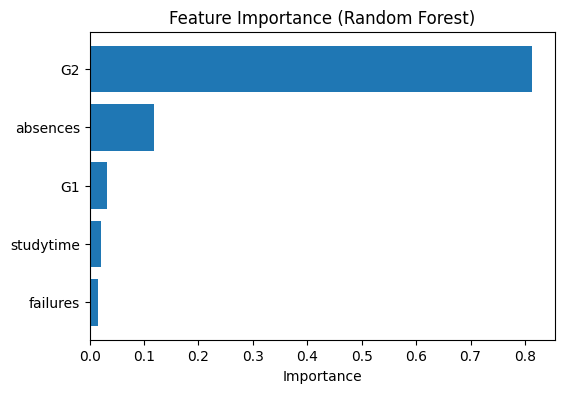

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": loaded_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)

plt.figure(figsize=(6,4))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [ ]:
def generate_feedback(input_df, prediction, importance_df):
    messages = []

    if input_df["G2"].values[0] < 10:
        messages.append("Your recent exam result (G2) is low and strongly affects your final grade.")

    if input_df["absences"].values[0] > 10:
        messages.append("High number of absences is negatively impacting your predicted performance.")

    if input_df["studytime"].values[0] <= 2:
        messages.append("Increasing your weekly study time may help improve your final grade.")

    if not messages:
        messages.append("Your academic indicators are generally positive. Maintain your current performance.")

    return messages


In [ ]:
# Re-create the sample input as a DataFrame (with feature names)
sample_input_df = X.iloc[[0]]  # double brackets to keep it as a DataFrame apparently idk why

# Predict again (safe and clean)
prediction = loaded_model.predict(sample_input_df)

# Generate feedback
feedback = generate_feedback(sample_input_df, prediction, importance_df)

print("Predicted final grade:", round(prediction[0], 2))
print("Feedback:")
for msg in feedback:
    print("-", msg)

Predicted final grade: 6.14
Feedback:
- Your recent exam result (G2) is low and strongly affects your final grade.
- Increasing your weekly study time may help improve your final grade.


Baseline Model Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Initialising the baseline model
lr_model = LinearRegression()

# Training the baseline model
lr_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Prediction on the test set
y_pred_lr = lr_model.predict(X_test)

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", round(mae_lr, 2))
print("R²:", round(r2_lr, 2))


Linear Regression Results
MAE: 1.34
R²: 0.78


In [ ]:
print("Model Comparison")
print("----------------")
print("Random Forest  -> MAE:", round(mae, 2), "| R²:", round(r2, 2))
print("Linear Reg.    -> MAE:", round(mae_lr, 2), "| R²:", round(r2_lr, 2))


Model Comparison
----------------
Random Forest  -> MAE: 1.05 | R²: 0.87
Linear Reg.    -> MAE: 1.34 | R²: 0.78


Conclusion

In [ ]:


import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ---- 1) Define features/target ----
# If you already did this earlier, keep it consistent:
keep_features = ["studytime", "failures", "absences", "G1", "G2"]
X = df[keep_features].copy()
y = df["G3"].copy()

# ---- 2) Preprocessing (safe even if all numeric) ----
numeric_features = keep_features

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

# ---- 3) Models ----
lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

# ---- 4) Cross-validation setup ----
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

def evaluate_cv(model, name):
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    mae = -results["test_mae"]  # convert neg MAE to positive MAE
    r2 = results["test_r2"]
    return {
        "Model": name,
        "MAE Mean": mae.mean(),
        "MAE Std": mae.std(),
        "R2 Mean": r2.mean(),
        "R2 Std": r2.std()
    }

summary = pd.DataFrame([
    evaluate_cv(lr, "Linear Regression (Baseline)"),
    evaluate_cv(rf, "Random Forest")
])

summary


,Model,MAE Mean,MAE Std,R2 Mean,R2 Std
0,Linear Regression (Baseline),1.182753,0.093357,0.818145,0.033127
1,Random Forest,1.021639,0.082174,0.857007,0.048594


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from Random Forest
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)


     Feature  Importance
4         G2    0.813853
2   absences    0.119140
3         G1    0.031818
0  studytime    0.020381
1   failures    0.014807


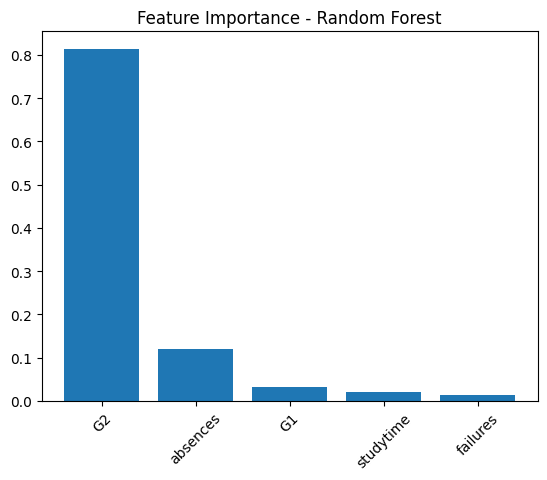

In [ ]:
plt.figure()
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.show()


In [ ]:
# Remove G2 to test early prediction scenario
X_no_g2 = X.drop(columns=["G2"])

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

rf_no_g2 = RandomForestRegressor(random_state=42)

mae_scores = -cross_val_score(
    rf_no_g2, X_no_g2, y,
    scoring="neg_mean_absolute_error",
    cv=5
)

r2_scores = cross_val_score(
    rf_no_g2, X_no_g2, y,
    scoring="r2",
    cv=5
)

print("Random Forest WITHOUT G2")
print("MAE Mean:", round(np.mean(mae_scores), 2))
print("R2 Mean:", round(np.mean(r2_scores), 2))


Random Forest WITHOUT G2
MAE Mean: 1.92
R2 Mean: 0.61


In [ ]:
import json
import pandas as pd
import joblib

# 1) Save model
joblib.dump(rf_model, "rf_model.pkl")

# 2) Save feature order (VERY IMPORTANT)
features = list(X.columns)
with open("features.json", "w") as f:
    json.dump(features, f)

# 3) Save a small background sample (optional but good for SHAP)
background = X.sample(min(200, len(X)), random_state=42)
background.to_csv("background.csv", index=False)

print("Saved: rf_model.pkl, features.json, background.csv")

Saved: rf_model.pkl, features.json, background.csv


Model Comparision and Evaluation

In [ ]:
#TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

FEATURES = ["studytime", "failures", "absences", "G1", "G2"]
TARGET = "G3"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df.sort_values("MAE")

,Model,MAE,RMSE,R2
1,Random Forest,1.051279,1.628626,0.870645
2,XGBoost,1.056506,1.631895,0.870126
0,Linear Regression,1.339416,2.113410,0.782175


In [ ]:
# 5-fold cross validation with KFold

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    mae_scores = -cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv)
    r2_scores = cross_val_score(model, X, y, scoring="r2", cv=cv)

    cv_results.append([
        name,
        mae_scores.mean(),
        mae_scores.std(),
        r2_scores.mean(),
        r2_scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "CV_MAE_mean", "CV_MAE_std", "CV_R2_mean", "CV_R2_std"]
).sort_values("CV_MAE_mean")

cv_df

,Model,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
1,Random Forest,1.021639,0.082174,0.857007,0.048594
2,XGBoost,1.084206,0.049080,0.845029,0.058043
0,Linear Regression,1.182753,0.093357,0.818145,0.033127


In [1]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
